# Build a deep learning model that can remove noise from images using an autoencoder on MNIST

## Week 6 Assessment

### Objective
The objective of this project is to develop a deep learning model capable of removing artificial noise from handwritten digit images using a Denoising Autoencoder. The model is trained on noisy versions of the MNIST dataset while using the original clean images as target outputs. After training, the model should reconstruct clean images from noisy inputs, demonstrating its ability to learn meaningful image representations.

## Step 1: Import Required Libraries

In this step, we import all the necessary libraries required for data preprocessing, visualization, model building, and training.

In [2]:
# Import numerical computation library
import numpy as np

# Import plotting library
import matplotlib.pyplot as plt

# Import TensorFlow
import tensorflow as tf

# Import MNIST dataset
from tensorflow.keras.datasets import mnist

# Import required layers
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# Import Model class
from tensorflow.keras.models import Model

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## Step 2: Load the MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images of size **28 × 28 pixels**. It consists of **60,000 training images** and **10,000 testing images**.

In [3]:
# Load the MNIST dataset
(x_train, _), (x_test, _) = mnist.load_data()

# Display dataset shapes
print("Training Images :", x_train.shape)
print("Testing Images  :", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training Images : (60000, 28, 28)
Testing Images  : (10000, 28, 28)


## Step 3: Preprocess the Dataset

Before training the model, the images are normalized to the range **0 to 1** by dividing each pixel value by 255. The images are then reshaped to include a channel dimension required for Convolutional Neural Networks (CNNs).

In [4]:
# Normalize pixel values to the range [0,1]
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Reshape images to include channel dimension
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Display shape after preprocessing
print("Training Shape:", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape: (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


## Step 4: Add Artificial Noise

To train a denoising autoencoder, artificial Gaussian noise is added to the clean images. The noisy images are used as inputs, while the original clean images are used as target outputs during training.

In [5]:
# Define noise level
noise_factor = 0.5

# Generate noisy training images
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

# Generate noisy testing images
x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

# Clip pixel values to remain within [0,1]
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

## Step 5: Visualize Original and Noisy Images

The following visualization compares the original MNIST images with their corresponding noisy versions.

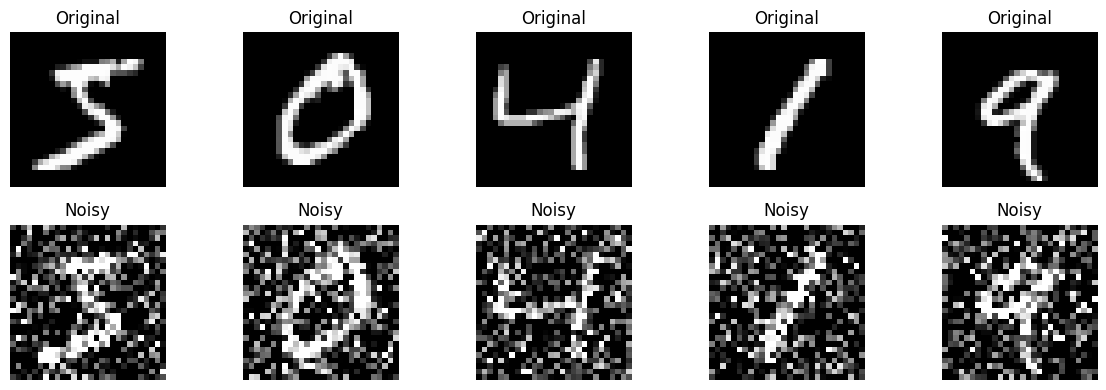

In [6]:
# Display original and noisy images
plt.figure(figsize=(12,4))

for i in range(5):

    # Original Image
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Step 6: Build the Denoising Autoencoder

The autoencoder consists of two main components:

- **Encoder:** Compresses the input image into a compact latent representation.
- **Decoder:** Reconstructs the clean image from the compressed representation.

Convolutional layers are used because they efficiently capture spatial features present in images.

In [7]:
# Define input layer
input_img = Input(shape=(28,28,1))

# ---------------- Encoder ---------------- #

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# ---------------- Decoder ---------------- #

x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

# Create autoencoder model
autoencoder = Model(input_img, decoded)

# Display model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Step 7: Compile the Model

The model is compiled using:

- **Optimizer:** Adam
- **Loss Function:** Binary Crossentropy

Adam provides efficient optimization, while Binary Crossentropy is suitable since pixel values are normalized between 0 and 1.

In [8]:
# Compile the autoencoder
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

## Step 8: Train the Denoising Autoencoder

The noisy images are provided as inputs, while the corresponding clean images are used as target outputs.

In [9]:
# Train the model
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 175s 368ms/step - loss: 0.1536 - val_loss: 0.1116
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 168s 357ms/step - loss: 0.1089 - val_loss: 0.1046
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 210s 374ms/step - loss: 0.1039 - val_loss: 0.1011
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 365ms/step - loss: 0.1012 - val_loss: 0.0993
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.0996 - val_loss: 0.0983
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 171s 364ms/step - loss: 0.0985 - val_loss: 0.0974
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 197s 354ms/step - loss: 0.0977 - val_loss: 0.0968
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 173s 368ms/step - loss: 0.0970 - val_loss: 0.0962
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 166s 353ms/step - loss: 0.0964 - val_loss: 0.0958
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 165s 353ms/step - loss: 0.0960 - val_loss: 0.0954
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 205s 360ms/step - loss: 0.0955 - val_loss: 0.0951
Epoch 12

## Step 9: Plot Training and Validation Loss

The loss curves help monitor the learning progress of the model and identify whether the model is converging properly.

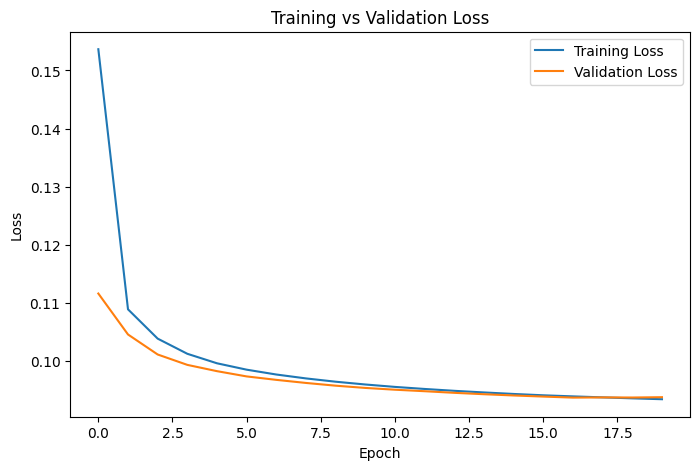

In [10]:
# Plot loss curves
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

## Step 10: Generate Denoised Images

The trained autoencoder is used to reconstruct clean images from noisy test images.

In [11]:
# Predict denoised images
decoded_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step


## Step 11: Compare Original, Noisy, and Reconstructed Images

The following visualization compares:

- Original Image
- Noisy Image
- Reconstructed (Denoised) Image

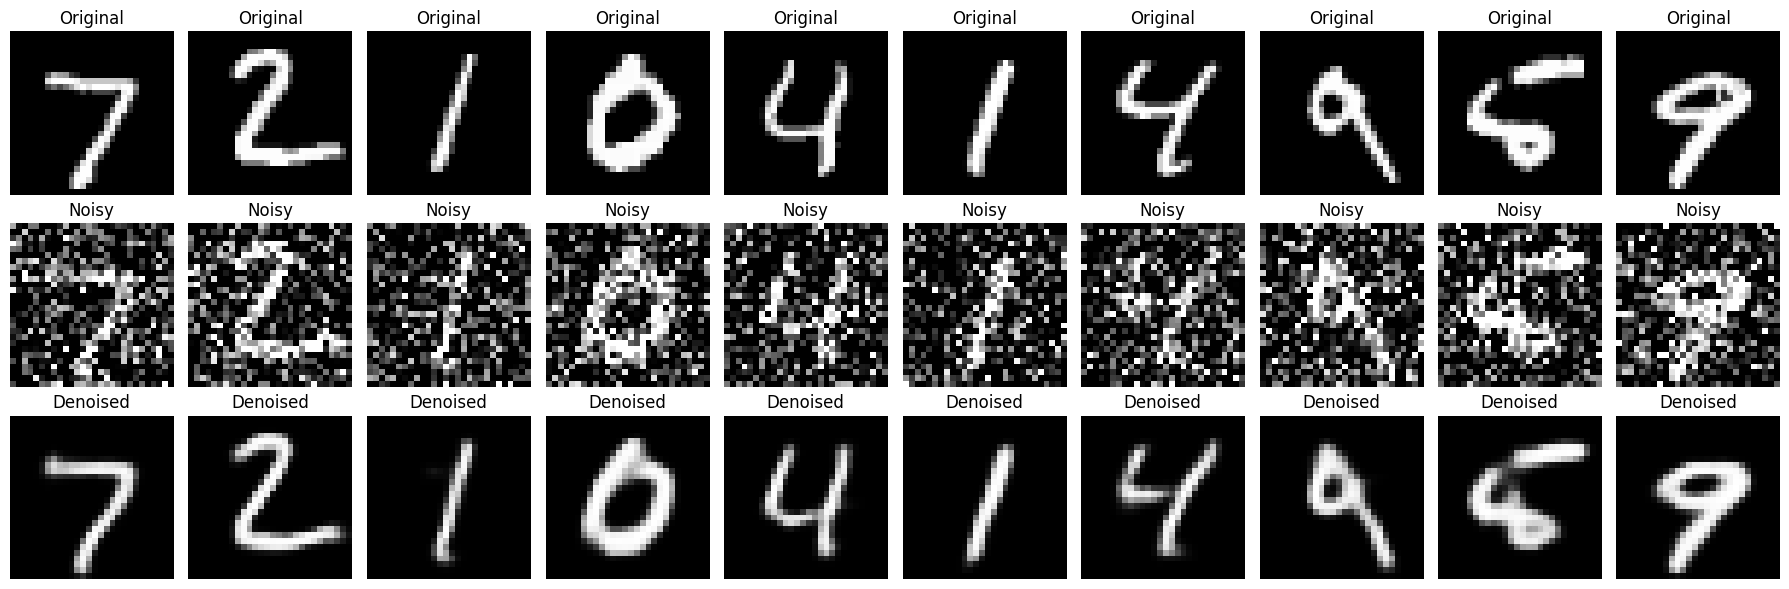

In [12]:
# Number of images to display
n = 10

plt.figure(figsize=(18,6))

for i in range(n):

    # Original
    plt.subplot(3,n,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(3,n,i+n+1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # Reconstructed
    plt.subplot(3,n,i+2*n+1)
    plt.imshow(decoded_images[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

# Observations

- The denoising autoencoder successfully learned to remove a significant portion of the Gaussian noise added to the input images.
- The reconstructed images preserved the overall structure and shape of the handwritten digits while reducing unwanted noise.
- As training progressed, both the training loss and validation loss consistently decreased, indicating effective learning and good convergence.
- Although some reconstructed digits appeared slightly smoother than the original images, the important digit features were retained.
- The convolutional architecture effectively captured spatial features, enabling the decoder to reconstruct cleaner images from compressed latent representations.

# Challenges

- Selecting an appropriate noise factor was important. Very high noise levels made reconstruction more difficult, while very low noise levels reduced the complexity of the learning task.
- Choosing a suitable number of epochs was necessary to ensure sufficient learning without excessive training time.
- Maintaining a balance between compression and reconstruction quality required careful design of the encoder and decoder architecture.

# Conclusion

A Convolutional Denoising Autoencoder was successfully implemented to remove Gaussian noise from MNIST handwritten digit images. The model was trained using noisy images as inputs and clean images as targets, enabling it to learn meaningful latent representations for image reconstruction. Experimental results demonstrated that the model effectively reduced noise while preserving the essential structure of the digits, confirming the suitability of autoencoders for image denoising tasks

# Different noise levels to test and compare

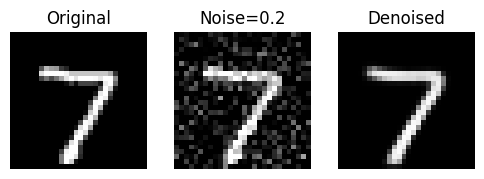

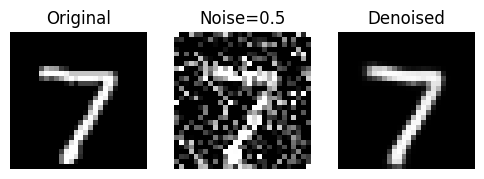

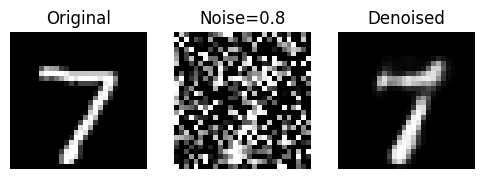

In [14]:
# Test different noise levels
for noise in [0.2,0.5, 0.8]:

    noisy = x_test[0] + noise * np.random.normal(size=x_test[0].shape)
    noisy = np.clip(noisy, 0., 1.)

    denoised = autoencoder.predict(noisy.reshape(1,28,28,1), verbose=0)

    plt.figure(figsize=(6,2))

    plt.subplot(1,3,1)
    plt.imshow(x_test[0].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.imshow(noisy.reshape(28,28), cmap='gray')
    plt.title(f"Noise={noise}")
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.imshow(denoised.reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

    plt.show()

# Analysis

As the noise level increases, the reconstruction becomes progressively smoother, and some fine details are lost. This behavior indicates that the model has learned meaningful latent representations but has limitations when handling extremely noisy inputs. Overall, the experiment demonstrates the robustness of the autoencoder across different noise intensities.